In [16]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.stats as si

In [ ]:
# PART 1: Binomial Option Pricing Model
# Computing the price of a European or American option using the multi-step Binomial model
import numpy as np

def Binomial_price(S,K,r,sigma,T,n,otype,EuOrAm):
    # We use this function to calculate the up/down factors and the risk-neutral probability.
    # With this information, we populate the tree holding the asset prices at different time steps,
    # the tree with intrinsic values at each node, and finally, the tree with the option prices.

    # The inputs of the function are: 
    # S: Spot price
    # K: Strike price
    # r: Risk-free rate (e.g., 0.05 for 5%)
    # sigma: Volatility
    # T: Time to maturity (in years)
    # n: Number of steps
    # otype: Call or Put
    # EuOrAm: European or American option

    dt = T/n  # Calculate the time step size

    u = np.exp(sigma*np.sqrt(dt)) # Calculate the up and down factors
    d = 1/u

    # Calculate the risk-neutral probability 
    # (We assume a non-dividend-paying stock to compute p)
    p = (np.exp(r*dt)-d)/(u-d) 
    
    # Initialize matrices to store the stock price, intrinsic value, and option value
    Stree = np.zeros((n+1, n+1))      
    Intrinsic = np.zeros((n+1, n+1))
    Option = np.zeros((n+1, n+1))
    
    # Loop to compute the Stock Price and Intrinsic Value trees
    for j in range(0, n+1):
        for i in range(0, j+1):
            # The nodes are generated by powers of u and d
            Stree[i,j] = S*(u**(j-i))*(d**(i))

            # Depending on whether it is a call or a put, we apply the specific payoff function
            if otype == "call":    
                Intrinsic[i,j] = np.maximum(Stree[i,j]-K, 0)
            elif otype == "put":
                Intrinsic[i,j] = np.maximum(K-Stree[i,j], 0)
            else:
                print("Wrong option type. Please write call or put")
            
      
    # Loop to compute the Option Price tree (Backward Induction)
    for j in range(n,-1,-1):
         for i in range(0, j+1):
            if j == n:
                # Boundary condition: At maturity, option value equals intrinsic value
                Option[i,j] = Intrinsic[i,j]
            else:
                # Discounting the expected value from the next step
                Option[i,j] = np.exp(-r*dt)*(Option[i,j+1]*p\
                                               +Option[i+1,j+1]*(1-p))
                
                # If American, we check for early exercise by comparing 
                # the continuation value with the intrinsic value at the node.
                if EuOrAm == "American":
                    Option[i,j] = np.maximum(Intrinsic[i,j], Option[i,j])
                
    return (Option[0,0])

In [31]:
#Exemple to see if the code works: 
Binomial_price(100,100,0.05,0.2,2,2,"call","European")

np.float64(14.84139177449445)

In [30]:
#Now with a lot of time steps: 
Binomial_price(100,100,0.05,0.2,2,100,"call","European")

np.float64(16.098572203636145)

In [ ]:
#Part 2: Black-Scholes Pricing Model
#Now we will see how the Multi-step binomial model converges to the Black-Scholes model once we keep adding steps
#First we define the Black-Scholes formula

def Black_Scholes(S,K,r,sigma,T,otype):
    
    #S: spot price
    #K: strike price
    #r: interest rate
    #sigma: volatility of underlying asset
    #T: time to maturity
    #otype: Call or Put
    
    # Calculate d1 and d2
    # d1 represents the delta-adjusted probability factor
    # d2 represents the probability of the option expiring in-the-money (risk-neutral)
    d1 = (np.log(S/K)+(r+0.5*sigma**2)*T)\
         /(sigma*np.sqrt(T))
    d2 = (np.log(S/K)+(r-0.5*sigma**2)*T)\
         /(sigma*np.sqrt(T))
    
    if otype == 'call':
        result = (S*si.norm.cdf(d1, 0.0, 1.0) \
                     -K*np.exp(-r*T)*si.norm.cdf(d2,0.0,1.0))
    elif otype == 'put':
        result = (K*np.exp(-r*T)*si.norm.cdf(-d2,0.0,1.0)\
                      -S*si.norm.cdf(-d1,0.0,1.0))
        
    return result

In [33]:
#Exemple to see if the code works: 
Black_Scholes(100,100,0.05,0.2,2,"call")

np.float64(16.126779724978633)

In [ ]:
# We can see numerically that the Black-Scholes option price is very similar to the 
# price obtained from the multi-step Binomial model with 100 steps.
# Now, we will confirm this graphically.

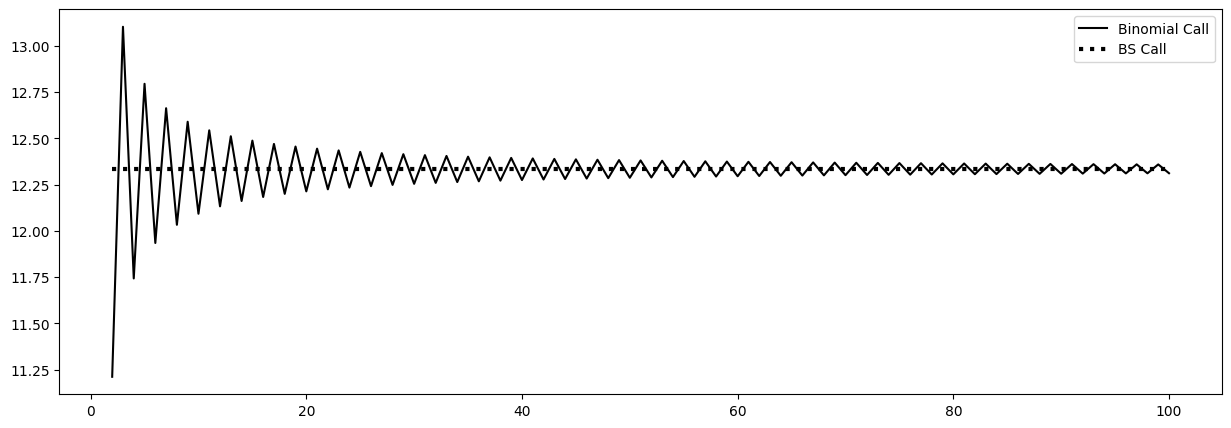

In [ ]:
# PART 3: Convergence Analysis (Visual Proof)
#First, we create a value to save all the Binomial model values
values=np.zeros((99))

#We define the initial values
S=100
K=100
r=0.05
sigma=0.25
T=1
otype="call"
EuOrAm ="European"

#With a for, we evaluate the Binomial model
# with different steps. In particular, from
# 2 to 100
for i in range(2,101):
    values[i-2] = Binomial_price(S, K, r, sigma, T, i, otype, EuOrAm)

#We create a figure
fig = plt.figure(figsize=(15,5))
#We plot all the values of the Binomial model
plt.plot(np.arange(2, 101, 1), values, 'k', label='Binomial Call')
#We plot a constant line with the value of the BS price
plt.hlines(y=Black_Scholes(100, 100, 0.05, 0.25, 1, 'call'),xmin=2, xmax=100,\
 linewidth=3,linestyles=':', color='k', label='BS Call')
plt.legend()
plt.show()